In [50]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit

In [51]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

KeyboardInterrupt: 

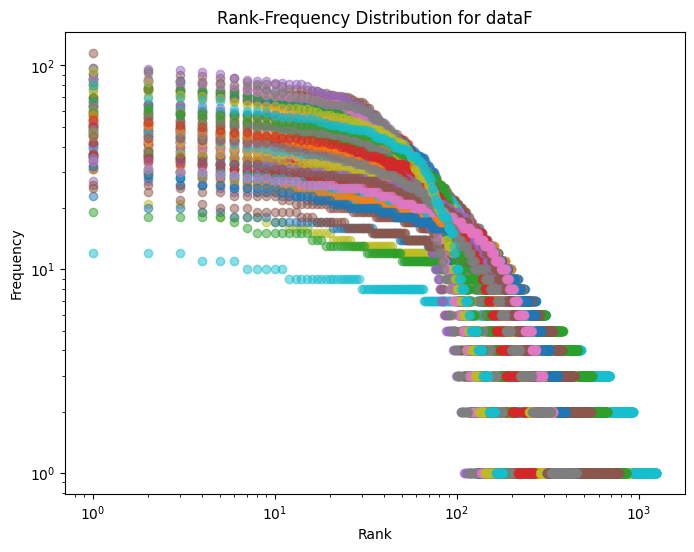

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))
files = [dataF, dataN, dataO, dataS, dataZ]
filenames = ['dataF', 'dataN', 'dataO', 'dataS', 'dataZ']
counter = 0

for file in files:
    for row in file:

        # FRD (Frequency-Rank Distribution)
        values, counts = np.unique(row, return_counts=True)
        freqs = np.sort(counts)[::-1]
        ranks = np.arange(1, len(freqs) + 1)

        ax.scatter(ranks, freqs, alpha=0.5)

    ax.set_xscale("log")   
    ax.set_yscale("log")  
    ax.set_xlabel("Rank")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Rank-Frequency Distribution for {filenames[counter]}")
    fig.savefig(f"RFD_{filenames[counter]}.png", dpi=300, bbox_inches="tight")

    counter += 1


C:\Users\rjnar\AppData\Local\Temp\ipykernel_21320\3759755789.py:16: RuntimeWarning: overflow encountered in power
  f = (w + s)**a / (w + w1)**(a + b)
C:\Users\rjnar\AppData\Local\Temp\ipykernel_21320\3759755789.py:16: RuntimeWarning: invalid value encountered in divide
  f = (w + s)**a / (w + w1)**(a + b)
C:\Users\rjnar\AppData\Local\Temp\ipykernel_21320\3759755789.py:19: RuntimeWarning: overflow encountered in power
  f_grid = (w_grid + s)**a / (w_grid + w1)**(a + b)
C:\Users\rjnar\AppData\Local\Temp\ipykernel_21320\3759755789.py:19: RuntimeWarning: invalid value encountered in divide
  f_grid = (w_grid + s)**a / (w_grid + w1)**(a + b)


Optimal fit parameters:
a = -86.82172949154995
b = 21.52841308667395


ValueError: s must be a scalar, or float array-like with the same size as x and y

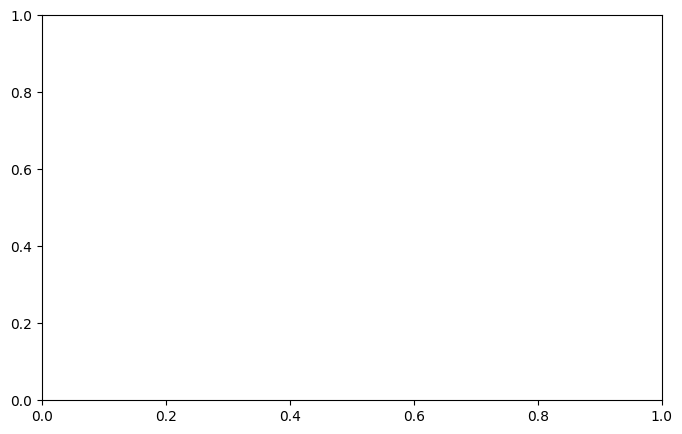

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import simpson

data = dataF[99]

# FRD
sorted_data = np.sort(data)[::-1]     
ranks = np.arange(1, len(sorted_data)+1)  


# Equation conversion
def f_model(rank, a, b, s=0.1, w1=1.0):
    w = rank.astype(float)
    f = (w + s)**a / (w + w1)**(a + b)

    w_grid = np.logspace(np.log10(min(w)), np.log10(max(w)), 500)
    f_grid = (w_grid + s)**a / (w_grid + w1)**(a + b)
    C = 1.0 / simpson(f_grid, x=w_grid)
    return C * f

# FITTING
popt, pcov = curve_fit(
    f_model,
    ranks,
    sorted_data,
    p0=[1.0, 2.0],   
    maxfev=20000     
)

a_fit, b_fit = popt
print("Optimal fit parameters:")
print("a =", a_fit)
print("b =", b_fit)

# ============================================
# Step 4: Plot results
# ============================================
plt.figure(figsize=(8,5))
# plt.loglog(ranks, sorted_data, 'bo', markersize=3, label="Data (rank-frequency)")
# plt.linlog(ranks, sorted_data, 'bo', markersize=3, label="Data (rank-frequency)")
plt.scatter(ranks, sorted_data, 'bo', markersize=3, label="Data (rank-frequency)")
# plt.set_yscale("log")
plt.set_xscale("log")
#plt.loglog(ranks, f_model(ranks, *popt), 'r-', linewidth=2,
#           label=f"Fit: a={a_fit:.2f}, b={b_fit:.2f}")
plt.xlabel("Rank")
plt.ylabel("Frequency / Size")
plt.title("Rank-Frequency Fit using Eq.(5), N=1")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()



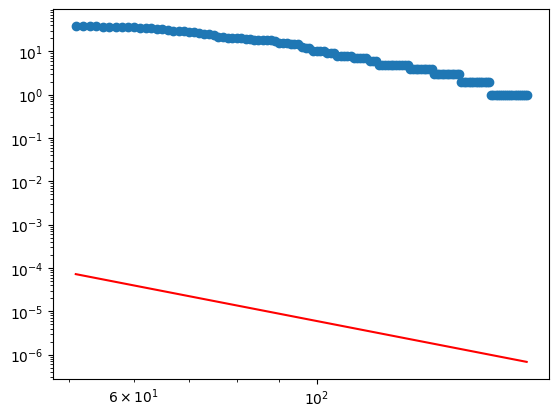

In [158]:
data = dataF[99]

def FRD(timeseries):
    """Build rank-frequency distribution."""

    values, counts = np.unique(timeseries, return_counts=True)
    freqs = np.sort(counts)[::-1]
    
    ranks = np.arange(1, len(freqs) + 1)
    return ranks, freqs

ranks, freqs = FRD(data)

# f1 fit = :40
# f2 fit = 40:
def f1(x,a):
    return x**(-a)

# plt.plot(ranks[:40], 75*f1(ranks[:40], 0.12), color='red')
# plt.scatter(ranks[:40], freqs[:40])
plt.plot(ranks[50:], 150*f1(ranks[50:], 3.7), color='red')
plt.scatter(ranks[50:], freqs[50:])
plt.xscale("log")
plt.yscale("log")
plt.show()

# a = 0.15


Fit 1 parameters: a = 0.1556, b = 81.5517
Fit 2 parameters: a = 2.1982, b = 272556.7383


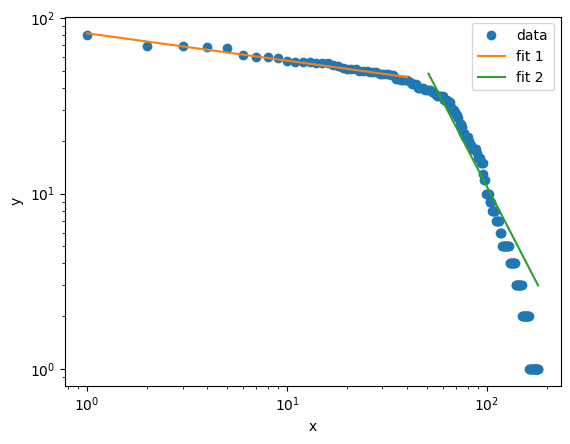

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define model (no need for two copies)
def f(x, a, b):
    return b * x**(-a)

slope, intercept = np.polyfit(np.log(ranks), np.log(freqs), 1)
a0 = -slope
b0 = np.exp(intercept)
p2 = [a0, b0]

# Initial guesses
p0 = [0.12, 75]
# p2 = [150, -0.37]  # cleaner scientific notation
# p2 = [10000000000, 4.4]

# # Fit first part
popt1, pcov1 = curve_fit(f, ranks[:40], freqs[:40], p0=p0)
a1, b1 = popt1
print(f"Fit 1 parameters: a = {a1:.4f}, b = {b1:.4f}")

# Fit second part
popt2, pcov2 = curve_fit(f, ranks[50:], freqs[50:], p0=p2)
a2, b2 = popt2
print(f"Fit 2 parameters: a = {a2:.4f}, b = {b2:.4f}")

# Plot data and fits
plt.loglog(ranks, freqs, "o", label="data")
plt.loglog(ranks[:40], f(ranks[:40], *popt1), "-", label="fit 1")
plt.loglog(ranks[50:], f(ranks[50:], *popt2), "-", label="fit 2")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


NameError: name 'ranks' is not defined

<Figure size 800x500 with 0 Axes>